In [7]:
import os
import torch
import torchvision
import tarfile
from torchvision.datasets.utils import download_url
import torchvision.transforms as tt
from torchvision.datasets import ImageFolder

In [8]:
# Dataset transforms (normalization & data augmentation)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_tfms = tt.Compose([
    tt.RandomCrop(32, padding=4, padding_mode='reflect'),
    tt.RandomHorizontalFlip(),
    tt.ToTensor(),
    tt.Normalize(*stats)
])
valid_tfms = tt.Compose([
    tt.ToTensor(),
    tt.Normalize(*stats)
])

# CIFAR-10 datasets
train_ds = torchvision.datasets.CIFAR10(root='./data',
                                             train=True,
                                             download=True,
                                             transform=train_tfms)

valid_ds = torchvision.datasets.CIFAR10(root='./data',
                                            train=False,
                                            download=True,
                                            transform=valid_tfms)

100%|██████████| 170M/170M [00:01<00:00, 102MB/s]  


In [9]:
# Pytorch data loader
from torch.utils.data import DataLoader

batch_size = 256
train_dl = DataLoader(train_ds, batch_size, shuffle=True,
                     num_workers=4, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size, shuffle=True,
                     num_workers=4, pin_memory=True)

In [10]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [11]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(16,16))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:100], 10).permute(1,2,0))
        break

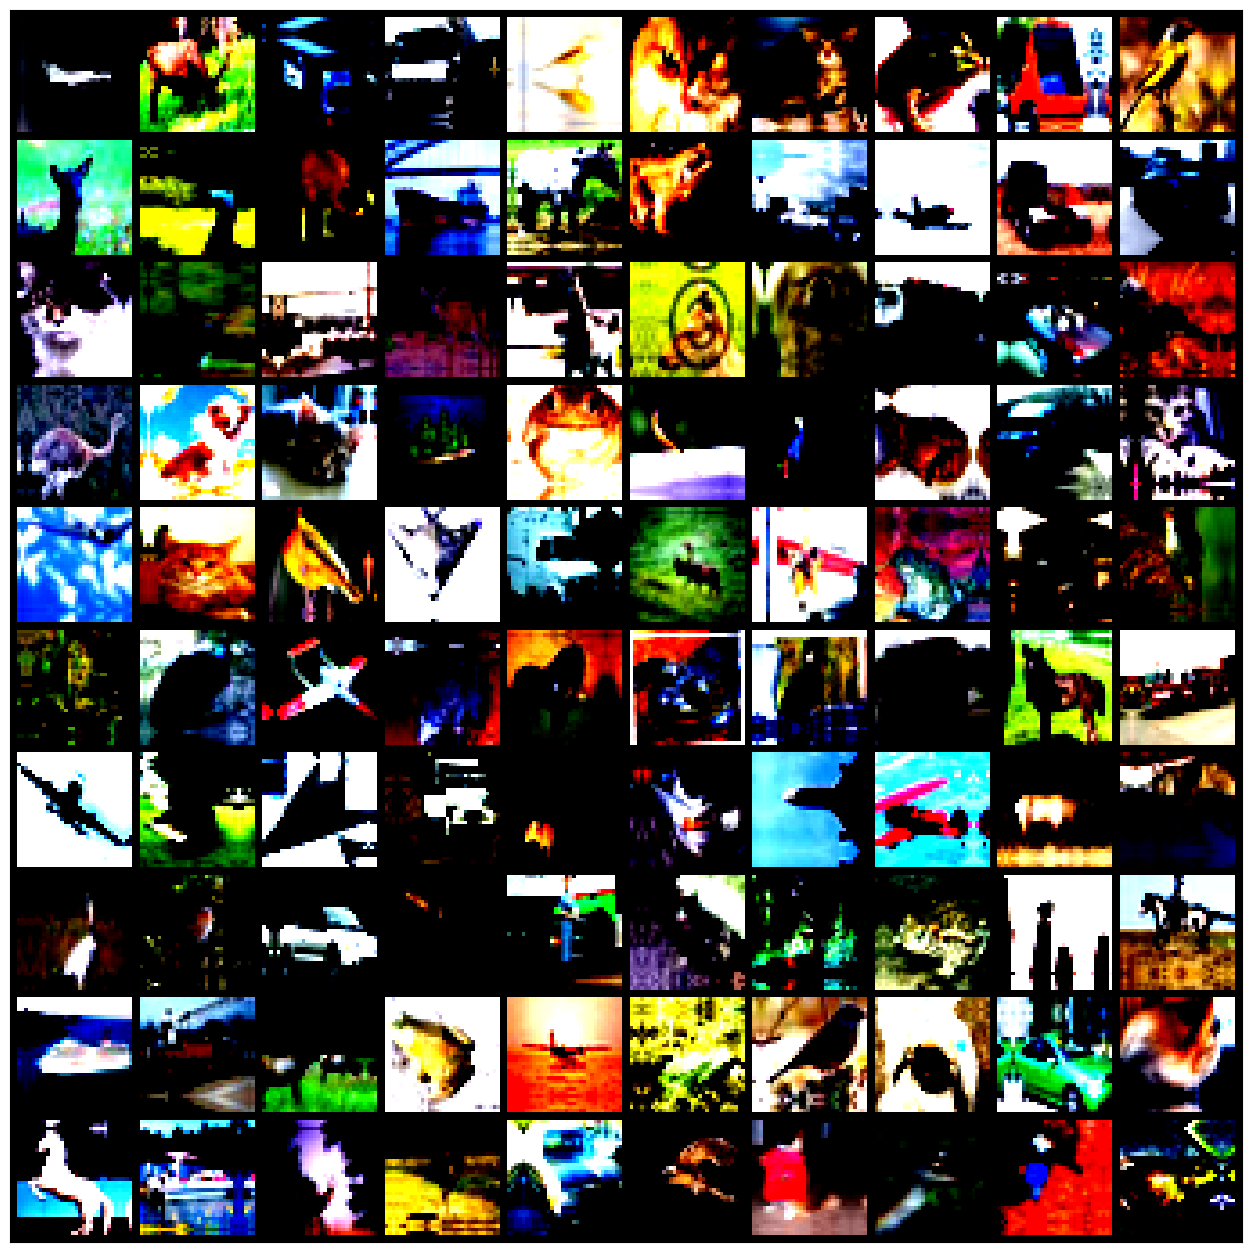

In [12]:
show_batch(train_dl)

In [13]:
import torch.nn as nn
import torch.nn.functional as F

In [14]:
class SimpleResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out + x)

In [15]:
simple_resnet = SimpleResidualBlock()

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break

torch.Size([256, 3, 32, 32])


In [16]:
def conv_2d(ni, nf, stride=1, ks=3):
    return nn.Conv2d(in_channels=ni, out_channels=nf,
                    kernel_size=ks, stride=stride,
                    padding=ks//2, bias=False)

def bn_relu_conv(ni, nf):
    return nn.Sequential(nn.BatchNorm2d(ni),
                        nn.ReLU(inplace=True),
                        conv_2d(ni, nf))

class ResidualBlock(nn.Module):
    def __init__(self, ni, nf, stride=1):
        super().__init__()
        self.bn = nn.BatchNorm2d(ni)
        self.conv1 = conv_2d(ni, nf, stride)
        self.conv2 = bn_relu_conv(nf, nf)
        self.shortcut = lambda x: x
        if ni != nf:
            self.shortcut = conv_2d(ni, nf, stride, 1)

    def forward(self, x):
        x = F.relu(self.bn(x), inplace=True)
        r = self.shortcut(x)
        x = self.conv1(x)
        x = self.conv2(x) * 0.2
        return x.add_(r)

In [17]:
def make_group(N, ni, nf, stride=1):
    start = ResidualBlock(ni, nf, stride)
    rest = [ResidualBlock(nf, nf) for j in range(1, N)]
    return [start] + rest

class Flatten(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x): return x.view(x.size(0), -1)

class WideResNet(nn.Module):
    def __init__(self, n_groups, N, n_classes, k=1, n_start=16):
        super().__init__()
        # Increase channels to n_start using conv layer
        layers = [conv_2d(3, n_start)]
        n_channels = [n_start]

        # Add groups of BasicBlock(increase channels & downsample)
        for i in range(n_groups):
            n_channels.append(n_start*(2**i)*k)
            stride = 2 if i>0 else 1
            layers += make_group(N, n_channels[i],
                                n_channels[i+1], stride)

        # Pool, flatten & add linear layer for classification
        layers += [nn.BatchNorm2d(n_channels[3]),
                  nn.ReLU(inplace=True),
                  nn.AdaptiveAvgPool2d(1),
                  Flatten(),
                  nn.Linear(n_channels[3], n_classes)]
        self.features = nn.Sequential(*layers)

    def forward(self, x): return self.features(x)

def wrn_22():
    return WideResNet(n_groups=3, N=3, n_classes=10, k=6)
        

In [18]:
model = wrn_22()

In [19]:
model

WideResNet(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ResidualBlock(
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(16, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Sequential(
        (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU(inplace=True)
        (2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (shortcut): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (2): ResidualBlock(
      (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Sequential(
        (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [20]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    break

images.shape: torch.Size([256, 3, 32, 32])
out.shape: torch.Size([256, 10])


In [21]:
from fastai.vision.all import *


# Wrap PyTorch datasets in DataLoaders (instead of DataBunch)
dls = DataLoaders.from_dsets(train_ds, valid_ds, bs=batch_size, shuffle=True)

# Create Learner (same as before)
learn = Learner(dls, model, loss_func=F.cross_entropy, metrics=accuracy)

# Gradient clipping (same attribute, still works in v2)
learn.clip = 0.1


SuggestedLRs(valley=0.0002754228771664202)

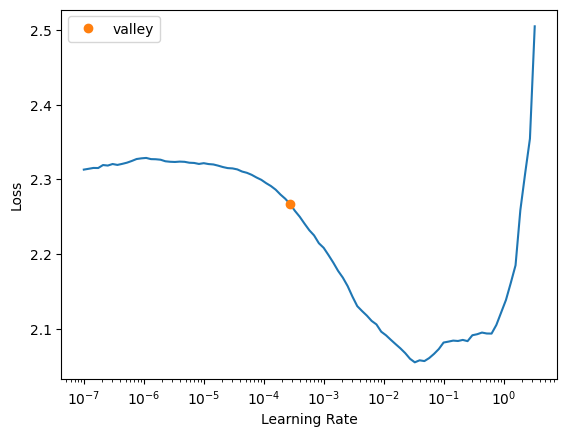

In [22]:
learn.lr_find()

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

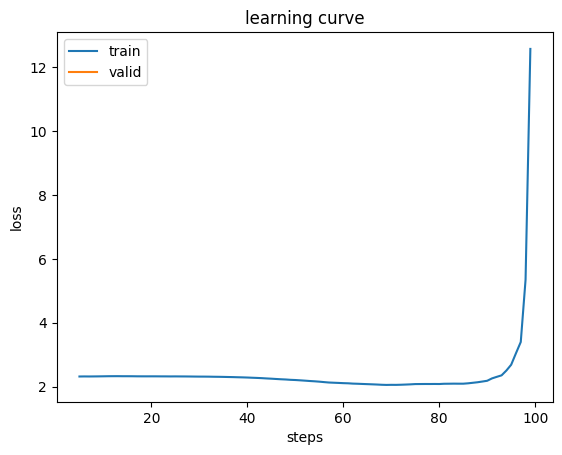

In [24]:
# Plot training/validation loss
learn.recorder.plot_loss()


In [ ]:
learn.fit_one_cycle(9, 5e-3, wd=1e-4)

epoch,train_loss,valid_loss,accuracy,time


In [ ]:
learn.recorder.plot_lr()

In [ ]:
learn.recorder.plot_losses()

In [ ]:
learn.recorder.plot_metrics()

In [ ]:
torch.save(model.state_dict(), 'cifar10-wrn22.pth')